In [1]:
import os
import time
import shutil
import pathlib
import itertools

# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# import Deep learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc
)


# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

2025-07-23 08:51:26.772202: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753260687.020868      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753260687.094380      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Define the data directory
data_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/'

# Initialize lists to store file paths and labels
filepaths = []
labels = []

# Traverse the directory structure
folds = ['test', 'train', 'val']
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    # Get the label directories (e.g., NORMAL, PNEUMONIA)
    label_dirs = os.listdir(foldpath)
    for label in label_dirs:
        labelpath = os.path.join(foldpath, label)
        # Get the list of files for the current label
        filelist = os.listdir(labelpath)
        for file in filelist:
            fpath = os.path.join(labelpath, file)
            filepaths.append(fpath)
            labels.append(label)

# Create pandas Series for filepaths and labels
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')

# Concatenate the Series into a DataFrame
df = pd.concat([Fseries, Lseries], axis=1)

# Display the DataFrame
print(df.head())

                                           filepaths     labels
0  /kaggle/input/chest-xray-pneumonia/chest_xray/...  PNEUMONIA
1  /kaggle/input/chest-xray-pneumonia/chest_xray/...  PNEUMONIA
2  /kaggle/input/chest-xray-pneumonia/chest_xray/...  PNEUMONIA
3  /kaggle/input/chest-xray-pneumonia/chest_xray/...  PNEUMONIA
4  /kaggle/input/chest-xray-pneumonia/chest_xray/...  PNEUMONIA


In [3]:
#Split dataframe into train, valid, and test
# train dataframe
train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123)

# valid and test dataframe
valid_df, test_df = train_test_split(dummy_df,  train_size= 0.6, shuffle= True, random_state= 123)

In [4]:
# crobed image size
batch_size = 32
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Recommended : use custom function for test data batch size, else we can use normal batch size.
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

# This function which will be used in image data generator for data augmentation, it just take the image and return it again.
def scalar(img):
    return img

tr_gen = ImageDataGenerator(preprocessing_function= scalar)
ts_gen = ImageDataGenerator(preprocessing_function= scalar)

train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

# Note: we will use custom test_batch_size, and make shuffle= false
test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= test_batch_size)

Found 4684 validated image filenames belonging to 2 classes.
Found 703 validated image filenames belonging to 2 classes.
Found 469 validated image filenames belonging to 2 classes.


In [5]:
# Count the number of images in each class for training data
train_class_counts = train_df['labels'].value_counts()
print("Training Data Class Counts:")
print(train_class_counts)

# Count the number of images in each class for validation data
valid_class_counts = valid_df['labels'].value_counts()
print("Validation Data Class Counts:")
print(valid_class_counts)

# Count the number of images in each class for test data
test_class_counts = test_df['labels'].value_counts()
print("Test Data Class Counts:")
print(test_class_counts)

Training Data Class Counts:
labels
PNEUMONIA    3417
NORMAL       1267
Name: count, dtype: int64
Validation Data Class Counts:
labels
PNEUMONIA    513
NORMAL       190
Name: count, dtype: int64
Test Data Class Counts:
labels
PNEUMONIA    343
NORMAL       126
Name: count, dtype: int64


In [6]:
 #Function to count the number of images in each class for a given dataframe
def get_class_counts(df):
    return df['labels'].value_counts()

# Get class counts for each dataset
train_class_counts = get_class_counts(train_df)
valid_class_counts = get_class_counts(valid_df)
test_class_counts = get_class_counts(test_df)

# Calculate total counts for each class
total_class_counts = train_class_counts.add(valid_class_counts, fill_value=0).add(test_class_counts, fill_value=0)

# Print the total counts
print("Total Class Counts:")
for label, count in total_class_counts.items():
    print(f"{label}: {count}")

Total Class Counts:
PNEUMONIA: 4273
NORMAL: 1583


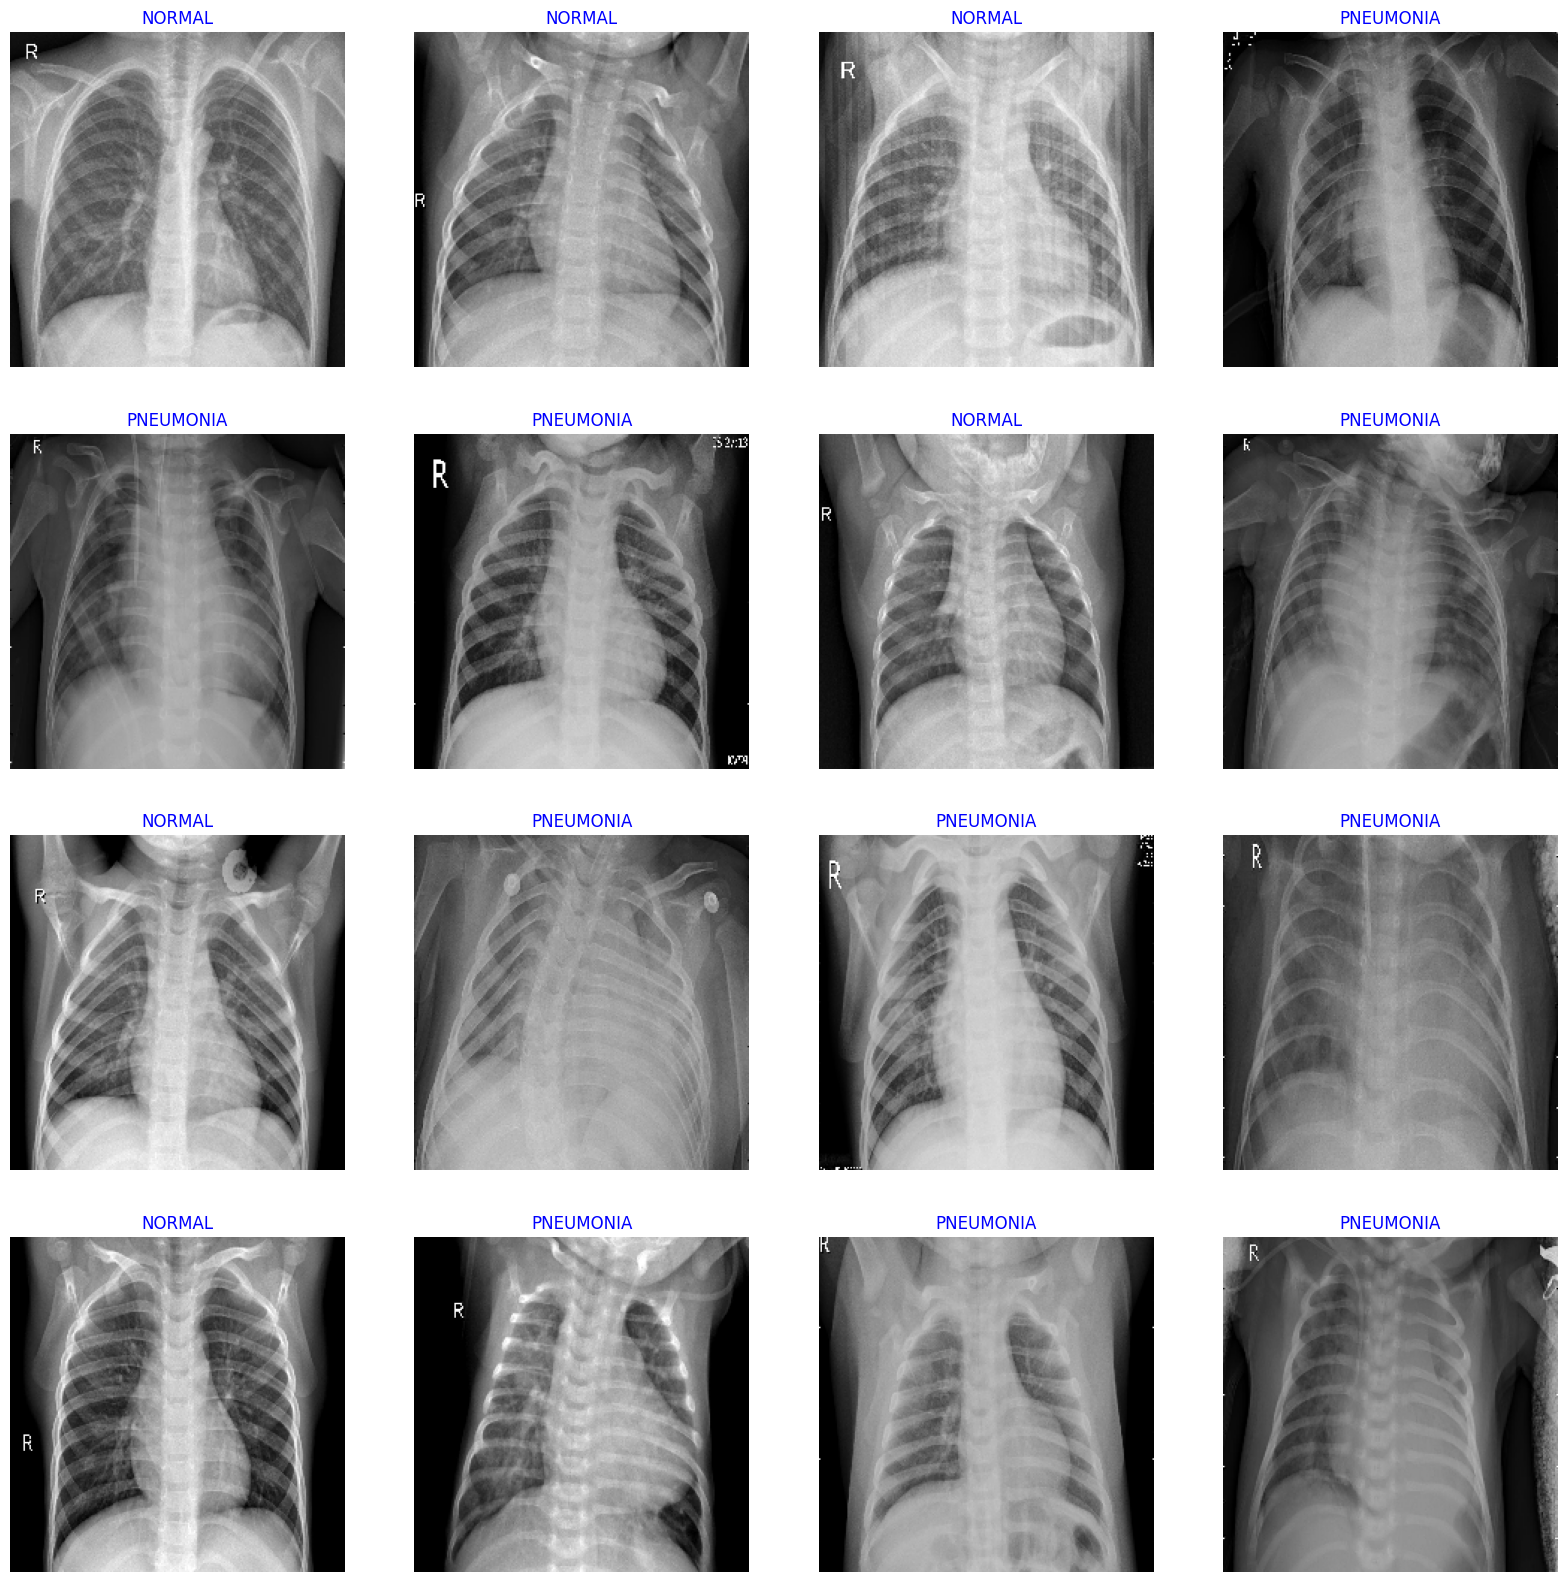

In [7]:
#Same sample from train data
g_dict = train_gen.class_indices      # defines dictionary {'class': index}
classes = list(g_dict.keys())       # defines list of dictionary's kays (classes), classes names : string
images, labels = next(train_gen)      # get a batch size samples from the generator

plt.figure(figsize= (20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255       # scales data to range (0 - 255)
    plt.imshow(image)
    index = np.argmax(labels[i])  # get image index
    class_name = classes[index]   # get class of image
    plt.title(class_name, color= 'blue', fontsize= 12)
    plt.axis('off')
plt.show()

In [8]:
# Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

img_shape=(224,224,3)
base_model = keras.applications.EfficientNetB0(include_top= False, weights= "imagenet",
                            input_shape= img_shape)
from tensorflow.keras.layers import LSTM,Bidirectional,Reshape
model = Sequential()
model.add(base_model)
model.add(Reshape((base_model.output.shape[1]*base_model.output.shape[2],base_model.output.shape[3])))
model.add(Bidirectional(LSTM(128, dropout=0.5,recurrent_dropout=0.4)))

model.add(Dense(class_count,activation = 'softmax'))

model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])
model.summary()

2025-07-23 08:52:02.910477: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 49, 1280)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 256)                 │       1,442,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,492,901 (20.95 MB)

 Trainable params: 5,450,878 (20.79 MB)

 Non-trainable params: 42,023 (164.16 KB)

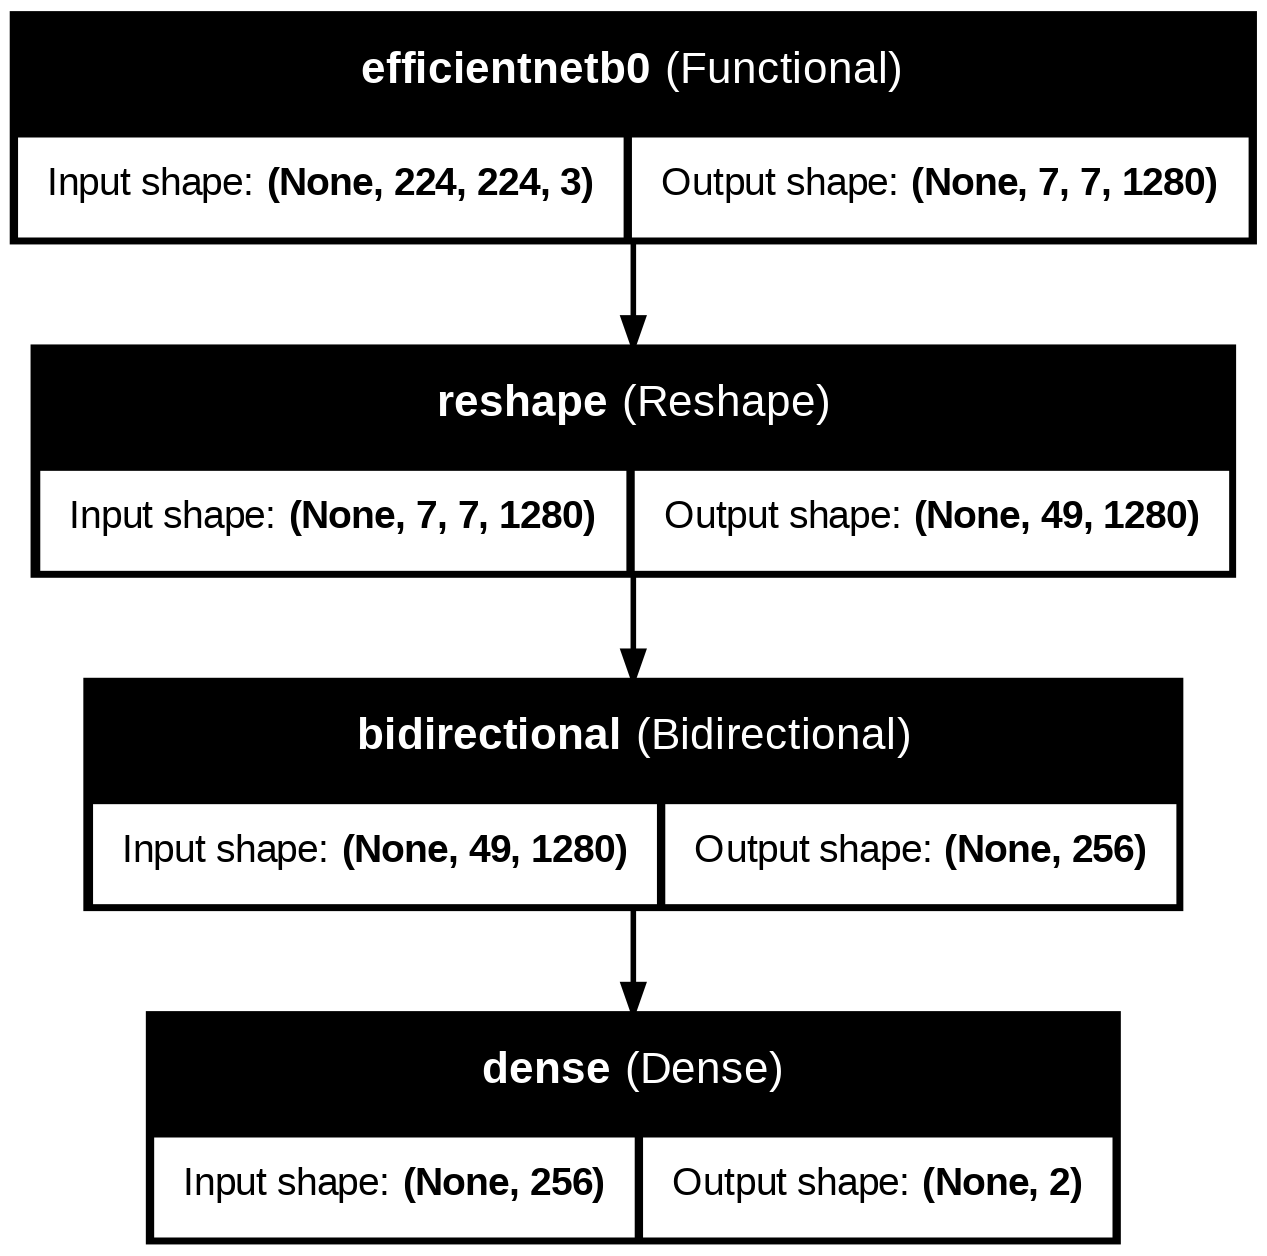

In [9]:
from tensorflow.keras.utils import plot_model
plot_model(model,show_shapes=True, show_layer_names=True, rankdir='TB')

In [10]:
batch_size = 32   # set batch size for training
epochs = 30   # number of all epochs in training

history = model.fit(x= train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen, 
                    validation_steps= None, shuffle= False)

Epoch 1/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 1057s 7s/step - accuracy: 0.9156 - loss: 0.2106 - val_accuracy: 0.9545 - val_loss: 0.1230
Epoch 2/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 987s 7s/step - accuracy: 0.9769 - loss: 0.0634 - val_accuracy: 0.9630 - val_loss: 0.1066
Epoch 3/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 973s 7s/step - accuracy: 0.9909 - loss: 0.0315 - val_accuracy: 0.9687 - val_loss: 0.0969
Epoch 4/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 952s 6s/step - accuracy: 0.9954 - loss: 0.0144 - val_accuracy: 0.9744 - val_loss: 0.0813
Epoch 5/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 987s 7s/step - accuracy: 0.9940 - loss: 0.0152 - val_accuracy: 0.9673 - val_loss: 0.0972
Epoch 6/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 951s 6s/step - accuracy: 0.9957 - loss: 0.0117 - val_accuracy: 0.9687 - val_loss: 0.1036
Epoch 7/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 954s 6s/step - accuracy: 0.9974 - loss: 0.0058 - val_accuracy: 0.9858 - val_loss: 0.0601
Epoch 8/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 975s 6s/step - accuracy: 0.9985 - loss: 0.0056 - val_acc

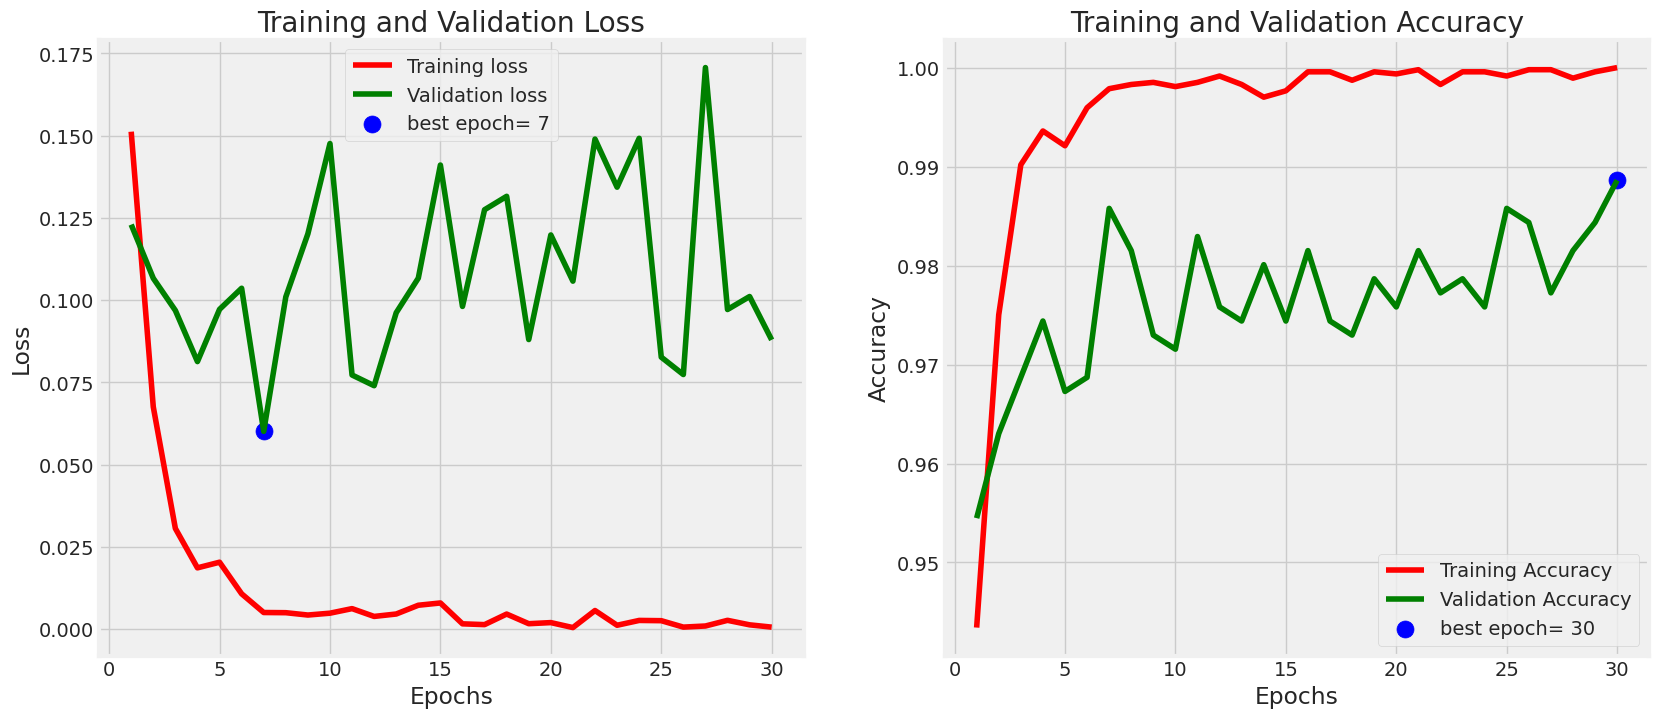

In [11]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [12]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 1.0000 - loss: 1.0630e-06
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9786 - loss: 0.0632
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9641 - loss: 0.3406
Train Loss:  2.796806938931695e-06
Train Accuracy:  1.0
--------------------
Validation Loss:  0.02809957042336464
Validation Accuracy:  0.9910714030265808
--------------------
Test Loss:  0.2751350700855255
Test Accuracy:  0.968017041683197


7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step


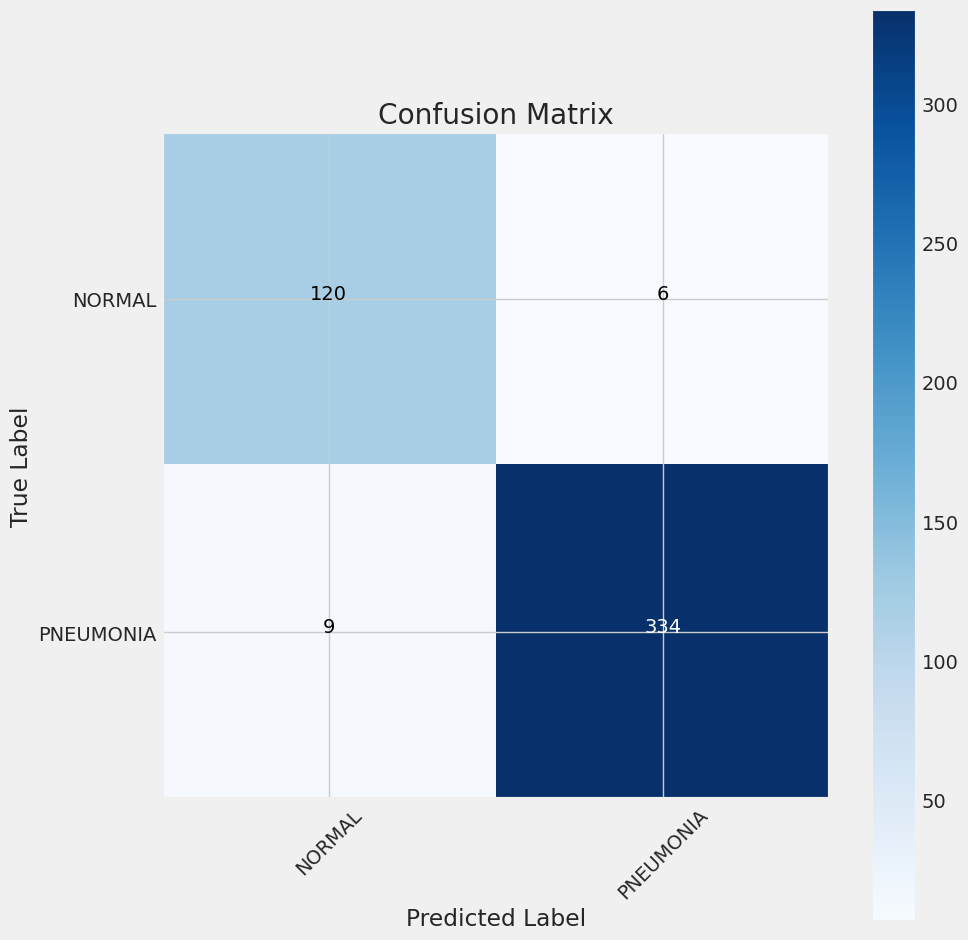

              precision    recall  f1-score   support

      NORMAL       0.93      0.95      0.94       126
   PNEUMONIA       0.98      0.97      0.98       343

    accuracy                           0.97       469
   macro avg       0.96      0.96      0.96       469
weighted avg       0.97      0.97      0.97       469

Accuracy: 0.9680
Precision: 0.9824
Recall: 0.9738
F1 Score: 0.9780


In [13]:
# Generate predictions
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

# Class labels
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred_classes)

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, cm[i, j], horizontalalignment='center', 
             color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print(classification_report(test_gen.classes, y_pred_classes, target_names=classes))

# Accuracy, precision, recall, F1 score
accuracy = accuracy_score(test_gen.classes, y_pred_classes)
precision = precision_score(test_gen.classes, y_pred_classes)
recall = recall_score(test_gen.classes, y_pred_classes)
f1 = f1_score(test_gen.classes, y_pred_classes)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')
